<a href="https://colab.research.google.com/github/welmi496/Generative-AI-Assignment13/blob/main/Assignment13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 13: Generative AI Essentials

## 1. Introduction

Generative AI refers to artificial intelligence systems that can create new content such as text, images, code, and audio by learning patterns from existing data. In this notebook, a simple character-level text generation model is implemented to demonstrate the basic idea of generative text modeling.

## Links:

- GitHub repository link: https://github.com/welmi496/Generative-AI-Assignment13/blob/main/Assignment13.ipynb

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt
import requests
import re

## 2. Dataset Preparation

For this assignment, the dataset is taken from **Project Gutenberg**. The selected text is **Alice's Adventures in Wonderland**, which is a public-domain book commonly used for text generation experiments.

In [3]:
# Download a small public-domain text from Project Gutenberg
url = "https://www.gutenberg.org/files/11/11-0.txt"  # Alice's Adventures in Wonderland
text = requests.get(url).text

# Keep the main book content only
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

start_idx = text.find(start_marker)
end_idx = text.find(end_marker)

if start_idx != -1 and end_idx != -1:
    text = text[start_idx:end_idx]

# Basic cleaning
text = re.sub(r'\r', ' ', text)
text = re.sub(r'\n+', '\n', text)
text = text[:50000]  # keep it small for faster Colab training

print(text[:1000])
print("\nTotal characters:", len(text))

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***
[Illustration]
Alice’s Adventures in Wonderland
by Lewis Carroll
THE MILLENNIUM FULCRUM EDITION 3.0
Contents
 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence
CHAPTER I.
Down the Rabbit-Hole
Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”
So she was considering in her own mind (as we

In [4]:
# Create character vocabulary
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print("Vocabulary size:", vocab_size)

Vocabulary size: 76


In [5]:
# Encode text as integers
encoded_text = np.array([char_to_idx[ch] for ch in text], dtype=np.int32)

seq_length = 100
X = []
y = []

for i in range(0, len(encoded_text) - seq_length):
    X.append(encoded_text[i:i+seq_length])
    y.append(encoded_text[i+seq_length])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49900, 100)
y shape: (49900,)


## 3. Model Implementation

The text generation model uses:
- an **Embedding** layer to represent characters numerically,
- an **LSTM** layer to learn sequence patterns,
- a **Dense** output layer with softmax activation to predict the next character.

In [6]:
# Build model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=seq_length),
    LSTM(128),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Training the Model

The model is trained to predict the next character in a sequence of 100 characters.

In [7]:
# Train model
history = model.fit(X, y, epochs=10, batch_size=128, validation_split=0.1)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 111s 308ms/step - accuracy: 0.2544 - loss: 2.8762 - val_accuracy: 0.2850 - val_loss: 2.6217
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 293ms/step - accuracy: 0.3261 - loss: 2.4435 - val_accuracy: 0.3263 - val_loss: 2.4348
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 287ms/step - accuracy: 0.3611 - loss: 2.2963 - val_accuracy: 0.3599 - val_loss: 2.3111
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 102s 291ms/step - accuracy: 0.3866 - loss: 2.1913 - val_accuracy: 0.3731 - val_loss: 2.2348
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 285ms/step - accuracy: 0.4052 - loss: 2.1088 - val_accuracy: 0.3964 - val_loss: 2.1680
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - accuracy: 0.4262 - loss: 2.0396 - val_accuracy: 0.4080 - val_loss: 2.1012
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 104s 296ms/step - accuracy: 0.4392 - loss: 1.9810 - val_accuracy: 0.4200 - val_loss: 2.0521
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 105s 300ms/step - accuracy: 0.4530 -

## 5. Training Results

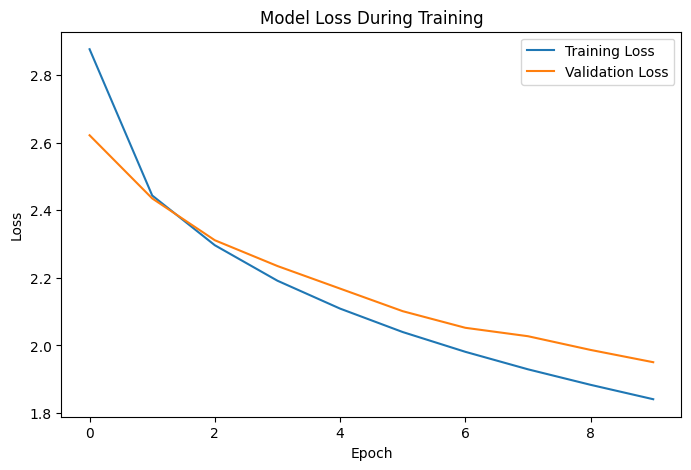

In [8]:
# Plot training history
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 6. Text Generation Function

In [9]:
def generate_text(model, seed_text, gen_length=400, temperature=1.0):
    input_seq = [char_to_idx.get(ch, 0) for ch in seed_text]
    generated = seed_text

    for _ in range(gen_length):
        padded_input = input_seq[-seq_length:]
        if len(padded_input) < seq_length:
            padded_input = [0] * (seq_length - len(padded_input)) + padded_input

        x_pred = np.array([padded_input])
        preds = model.predict(x_pred, verbose=0)[0]

        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        next_index = np.random.choice(len(preds), p=preds)
        next_char = idx_to_char[next_index]

        generated += next_char
        input_seq.append(next_index)

    return generated

## 7. Generate Text from Seed Input

In [10]:
seed = "Alice was beginning to"
generated_output = generate_text(model, seed_text=seed, gen_length=500, temperature=0.8)
print(generated_output)

Alice was beginning to wet saired to wought bockith her in the haid the bittait.
“Went way thing goore
bather out it then then sus).
There these ow ade that and of batty fanged seet, and nown’t ont one heme hood it, and nown on hersery, and begh like
sas make. “It whenden I little was for mint to the out rear!”
What back
yout doold to wo down, and the has that hards rooke.
Afs a shan onning in lory be the was looked fonce, and
in the heck to coment of like pound and a fide
down a the rapking in the go
down she wis a 


## 8. Application Demonstration

A simple practical application of this model is **content creation**. The model can generate text continuations from a short prompt, which can be useful for brainstorming, story writing, or drafting ideas.

In [11]:
# Simple practical demonstration: content creation
prompt = "The future of artificial intelligence is"
demo_output = generate_text(model, seed_text=prompt, gen_length=300, temperature=0.9)

print("Seed Prompt:")
print(prompt)
print("\nGenerated Content:")
print(demo_output)

Seed Prompt:
The future of artificial intelligence is

Generated Content:
The future of artificial intelligence is qune!” Cous the wisht to then mirsn then wicull
to ke bangand of criter fir vewt intom it yone’mn.
“Ner shiled foor it rabbice over to at treles and had the cused it swat the utonch, I pormoredud rat out and up I The bunt
“Whow, (Fe-salm bereaneting she out to ale taix tor a is toun,” bit this liex
